CASE STUDY 3: Brain Tumor Detection using CNN + Grad-CAM

In [52]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [53]:

# 1. Download Dataset
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Path to dataset files: /kaggle/input/brain-tumor-classification-mri


In [54]:
# Define paths based on the Sartaj dataset structure
train_dir = os.path.join(path, 'Training')
test_dir = os.path.join(path, 'Testing')


In [55]:

# 2. Data Preparation
img_size = 150 # Resizing to 150x150 is standard for this dataset to save memory
batch_size = 32


In [56]:

# Adding Data Augmentation to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [57]:

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical' # 4 classes: Glioma, Meningioma, No Tumor, Pituitary
)

val_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [58]:
# 3. Model Architecture
model = models.Sequential([
    # Convolutional Base
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Helps prevent overfitting
    layers.Dense(4, activation='softmax') # 4 classes
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [59]:
# 4. Training
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.4408 - loss: 1.2344 - val_accuracy: 0.2614 - val_loss: 1.8934
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.5749 - loss: 0.9816 - val_accuracy: 0.3731 - val_loss: 2.0798
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.6425 - loss: 0.8214 - val_accuracy: 0.3325 - val_loss: 2.8005
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.6812 - loss: 0.7294 - val_accuracy: 0.3706 - val_loss: 2.4416
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.7024 - loss: 0.6999 - val_accuracy: 0.4416 - val_loss: 2.4709
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.7247 - loss: 0.6446 - val_accuracy: 0.4061 - val_loss: 2.8908
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.7397 - loss: 0.6219 - val_accuracy: 0.3883 - val_loss: 2.4441
Epoch 8/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.7481 - loss: 0.5839 - val_accuracy: 0.4619 - v

In [60]:
# 5. Evaluation and Visualization
loss, accuracy = model.evaluate(val_generator)
print(f"\nFinal Validation Accuracy: {accuracy*100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 420ms/step - accuracy: 0.5025 - loss: 3.3837

Final Validation Accuracy: 50.25%


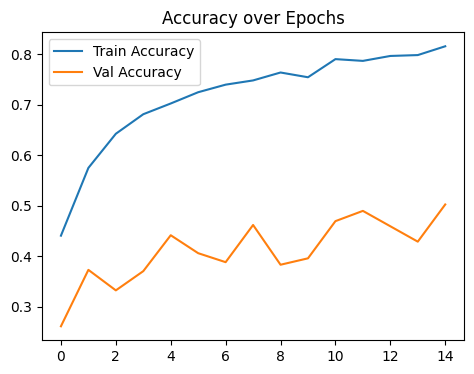

In [61]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

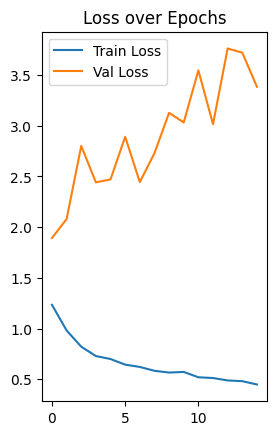

In [62]:
# Plotting
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()